In [1]:
import os
os.environ.pop("CUDA_VISIBLE_DEVICES", None)
# or force it:
# os.environ["CUDA_VISIBLE_DEVICES"] = "0"

import torch

print("CUDA_VISIBLE_DEVICES:", os.environ.get("CUDA_VISIBLE_DEVICES"))
print("cuda available:", torch.cuda.is_available())
print("device count:", torch.cuda.device_count())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No CUDA")

CUDA_VISIBLE_DEVICES: None
cuda available: True
device count: 1
NVIDIA GeForce RTX 3070 Laptop GPU


In [2]:
import os
SEED = 67


import gc
import sys
from pathlib import Path

import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd
import json
from datetime import datetime
from scipy import signal

print("torch:", torch.__version__)
print("cuda build:", torch.version.cuda)
print("cuda available:", torch.cuda.is_available())
print("cuda device count:", torch.cuda.device_count())
if torch.cuda.is_available():
    print("cuda device name:", torch.cuda.get_device_name(0))
    torch.cuda.empty_cache()
    torch.cuda.synchronize()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

torch.manual_seed(SEED)

torch: 2.12.0+cu126
cuda build: 12.6
cuda available: True
cuda device count: 1
cuda device name: NVIDIA GeForce RTX 3070 Laptop GPU
cuda


In [3]:
from pngtojson import points_to_intensity_grid, png_to_xy_intensity, png_to_xy_binary

In [4]:
def load_data(folder_path):
    # Load the data from the specified folder
    data = dict()
    count = 0 
    for file_name in os.listdir(folder_path):
        if file_name.endswith('.png'):
            intensity_points = png_to_xy_intensity(os.path.join(folder_path, file_name),include_zero=True)
            #intensity_points = png_to_xy_binary(os.path.join(folder_path, file_name),include_zero=True)
            intensity_grid = points_to_intensity_grid(intensity_points )
            intensity_df = pd.DataFrame(intensity_grid)
            intensity_df = intensity_df / 100.0
            data[file_name] = intensity_df
            count += 1
    print(f"Loaded {count} images.")
    
    return data

In [5]:
#prev_key = first_key
def create_samples(data, list_length=10, min_list_length = 7):
    count = 1 
    data_grouped = list()
    sample_list= list()
    
    
    ttl_cnt = 0 
    keys = sorted(data.keys())
    prev_key = keys[0]

    for key in keys[1:]:
        value = data[key]
        value= torch.from_numpy(value.to_numpy()).float()
        ttl_cnt+=1
        key_time = datetime.strptime(str(key).strip(".png"),"%Y%m%d%H%M")
        prev_key_time = datetime.strptime(str(prev_key).strip(".png"),"%Y%m%d%H%M")
        change = key_time - prev_key_time
        change = int(change.seconds/60)
        #print(f"doing key {key}, with change {change}, cureent length is {len(sample_list)}, with count {count}")
        
    
        if change > 5: # if non continous jump, end sample
            #data_grouped.append(sample_list)
            print(f"sample with lenth {len(sample_list)} created due to discontinuation in series, with change {change}")
            sample_list = list()
            sample_list.append(value)
            
            count=1
            
        elif change == 5 and count <list_length: # add value to sample if we arent at the limit
            sample_list.append(value)
            
            #print("appended")
            count += 1 
            
        elif change == 5 and count >= list_length: # shelve sample and start a new sample
            data_grouped.append(sample_list)
           # print(f"sample with lenth {len(sample_list)} created")
            sample_list = list()
            sample_list.append(value)
            
            count=1
        else:
            print("FUCCCKKK YOU FOING HERE" ) # should never reach this
        
        prev_key = key # pass on key information 
        
    #removing samples too short
    filtered=list()
    for idx, item in enumerate(data_grouped):
        length = len(item)

        if length < min_list_length:
           pass
        else:
            filtered.append(item)
    #print(f"removed {len(data_grouped)- len(filtered)} items for length")
    data_grouped = filtered
    x=list()
    y=list()

    for i in data_grouped:
        length= len(i)
        
        #print(length)
        last = i.pop(length-1)
        length= len(i)
        
        x.append(i)
        y.append(last)
        
    return x,y
            
            


In [6]:
import os
import pandas as pd
from torch.utils.data import Dataset


class radar_dataset(Dataset):
    def __init__(self, folderloc , list_length=10, min_list_length = 10):
        min_list_length = list_length
        
        self.data = load_data(folderloc)
        self.x, self.y = create_samples(self.data,  list_length=list_length, min_list_length = min_list_length)
        
        
        
    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        sample = self.x[idx]
        target = self.y[idx]
        
        sample = torch.stack(sample).unsqueeze(1).float()
        target = torch.tensor(target, dtype=torch.float32)
        return sample, target

In [7]:
sample_size= 4 
dataset= radar_dataset("C:\\Users\\Jacobs laptop\\rainraingoaway\\data\\70km\\png", list_length=sample_size)
split_idx = int(0.8 * len(dataset))


train_dataset = torch.utils.data.Subset(dataset, range(0, split_idx))
test_dataset = torch.utils.data.Subset(dataset, range(split_idx, len(dataset)))

Loaded 3948 images.
sample with lenth 1 created due to discontinuation in series, with change 10
sample with lenth 1 created due to discontinuation in series, with change 15
sample with lenth 3 created due to discontinuation in series, with change 10
sample with lenth 2 created due to discontinuation in series, with change 10
sample with lenth 2 created due to discontinuation in series, with change 10
sample with lenth 1 created due to discontinuation in series, with change 10
sample with lenth 1 created due to discontinuation in series, with change 10
sample with lenth 2 created due to discontinuation in series, with change 10
sample with lenth 1 created due to discontinuation in series, with change 10
sample with lenth 1 created due to discontinuation in series, with change 10
sample with lenth 4 created due to discontinuation in series, with change 10
sample with lenth 2 created due to discontinuation in series, with change 10
sample with lenth 3 created due to discontinuation in se

C:\TEMP\ipykernel_10732\518825637.py:14: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:219.)
  value= torch.from_numpy(value.to_numpy()).float()


sample with lenth 3 created due to discontinuation in series, with change 10
sample with lenth 1 created due to discontinuation in series, with change 10
sample with lenth 2 created due to discontinuation in series, with change 10
sample with lenth 4 created due to discontinuation in series, with change 10
sample with lenth 1 created due to discontinuation in series, with change 10
sample with lenth 3 created due to discontinuation in series, with change 10
sample with lenth 4 created due to discontinuation in series, with change 10
sample with lenth 2 created due to discontinuation in series, with change 10
sample with lenth 3 created due to discontinuation in series, with change 10
sample with lenth 3 created due to discontinuation in series, with change 10
sample with lenth 2 created due to discontinuation in series, with change 10
sample with lenth 2 created due to discontinuation in series, with change 10
sample with lenth 2 created due to discontinuation in series, with change 10

In [8]:
from torch.utils.data import DataLoader
BATCH_SIZE = 16 
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
print(f"Train samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")
print(f"Train batches :{len(train_loader)}")
print(f"Test batches :{len(test_loader)}")

Train samples: 756
Test samples: 189
Train batches :48
Test batches :12


In [9]:
for inputs, labels in train_loader:
    print("inputs shape:", inputs.shape)
    print("labels shape:", labels.shape)
    break

inputs shape: torch.Size([16, 3, 1, 120, 217])
labels shape: torch.Size([16, 120, 217])


C:\TEMP\ipykernel_10732\3276092173.py:23: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  target = torch.tensor(target, dtype=torch.float32)


In [10]:
#import model
from mode import radar_cnn
from models.convlstm import ConvLSTM

model = ConvLSTM(input_dim=1,
                 hidden_dim=64,
                 kernel_size=(3, 3),
                 num_layers=2,
                 batch_first=True,
                 bias=True)


model = model.to(device)

In [11]:
#define loss function
import torch.optim
optimizer = torch.optim.SGD(model.parameters(), lr=0.005)
loss_fn = torch.nn.MSELoss()
loss_fn = torch.nn.SmoothL1Loss() # try image diff loss 
loss_fn = torch.nn.BCEWithLogitsLoss(pos_weight=torch.tensor([30.0]).to(device))

In [12]:
def train_one_epoch(epoch_index, optimizer, model, loss_fn):
    running_loss = 0 
    last_loss = 0 
    for i , data in enumerate(train_loader):
        inputs, labels= data 
        inputs = inputs.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        layer_output_list = model(inputs)

        outputs = layer_output_list
        
        #if labels.dim() == 3:
         #   labels = labels.unsqueeze(1)  # [batch, 120, 217] -> [batch, 1, 120, 217]
        
        #print(f"label: {labels.shape}")
        #print(f"output: {outputs.shape}")
        outputs= outputs.squeeze(1)
        #print(outputs.shape)
        loss = loss_fn(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        if i % 10 == 9:
            last_loss = running_loss / 10 # loss per batch
            print(f'  batch {i + 1} loss: {last_loss}')
            tb_x = epoch_index * len(train_loader) + i + 1
           
            running_loss = 0.
    return last_loss  

In [13]:


epoch_number = 0
val=[]
train=[]
EPOCHS = 200

best_vloss = 1000000000000000


for epoch in range(EPOCHS):
    print(f'EPOCH {epoch_number + 1}:')

    # Make sure gradient tracking is on, and do a pass over the data
    model.train(True)
    avg_train_loss = train_one_epoch(epoch_number, optimizer,model,loss_fn)


    running_vloss = 0.0
    # Set the model to evaluation mode, disabling dropout and using population
    # statistics for batch normalization.
    model.eval()

    # Disable gradient computation and reduce memory consumption.
    with torch.no_grad():
        for i, vdata in enumerate(test_loader):
            vinputs, vlabels = vdata
            vinputs = vinputs.to(device)
            vlabels = vlabels.to(device)
            layer_output_list = model(vinputs)

            voutputs = layer_output_list.squeeze(1)
            vloss = loss_fn(voutputs, vlabels.float())
            # [B, T, C, H, W] -> [B, C, H, W]
            running_vloss += vloss

    avg_val_loss = running_vloss / (i + 1)
    print(f'LOSS train {avg_train_loss} valid {avg_val_loss}')
    val.append(avg_val_loss.item())
    train.append(avg_train_loss)

    # Log the running loss averaged per batch
    # for both training and validation


    # Track best performance, and save the model's state
    if avg_val_loss < best_vloss:
        best_vloss = avg_val_loss
        model_path = f'model_best.pkl' .
        torch.save(model.state_dict(), model_path,)

    epoch_number += 1

EPOCH 1:


C:\TEMP\ipykernel_10732\3276092173.py:23: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  target = torch.tensor(target, dtype=torch.float32)


  batch 10 loss: 0.9680271446704865
  batch 20 loss: 0.8640730857849122
  batch 30 loss: 1.050123119354248
  batch 40 loss: 0.871901947259903
LOSS train 0.871901947259903 valid 0.7256201505661011
EPOCH 2:
  batch 10 loss: 0.8964648425579071
  batch 20 loss: 0.8679970681667328
  batch 30 loss: 0.9208602547645569
  batch 40 loss: 0.9217267870903015
LOSS train 0.9217267870903015 valid 0.6970199346542358
EPOCH 3:
  batch 10 loss: 0.8174458920955658
  batch 20 loss: 0.9486854314804077
  batch 30 loss: 0.9061883807182312
  batch 40 loss: 0.8657926142215728
LOSS train 0.8657926142215728 valid 0.6720787882804871
EPOCH 4:
  batch 10 loss: 0.7864689886569977
  batch 20 loss: 0.9190325081348419
  batch 30 loss: 0.804408049583435
  batch 40 loss: 0.9068824589252472
LOSS train 0.9068824589252472 valid 0.650075376033783
EPOCH 5:
  batch 10 loss: 0.8858173012733459
  batch 20 loss: 0.8021885931491852
  batch 30 loss: 0.7680579602718354
  batch 40 loss: 0.9358716607093811
LOSS train 0.9358716607093811

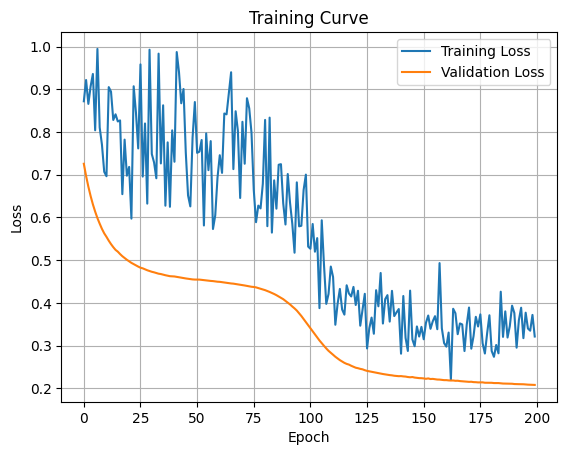

In [14]:
import matplotlib.pyplot as plt

plt.plot(train, label="Training Loss")
plt.plot(val, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Curve")
plt.legend()
plt.grid(True)
plt.show()

C:\TEMP\ipykernel_10732\3276092173.py:23: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  target = torch.tensor(target, dtype=torch.float32)


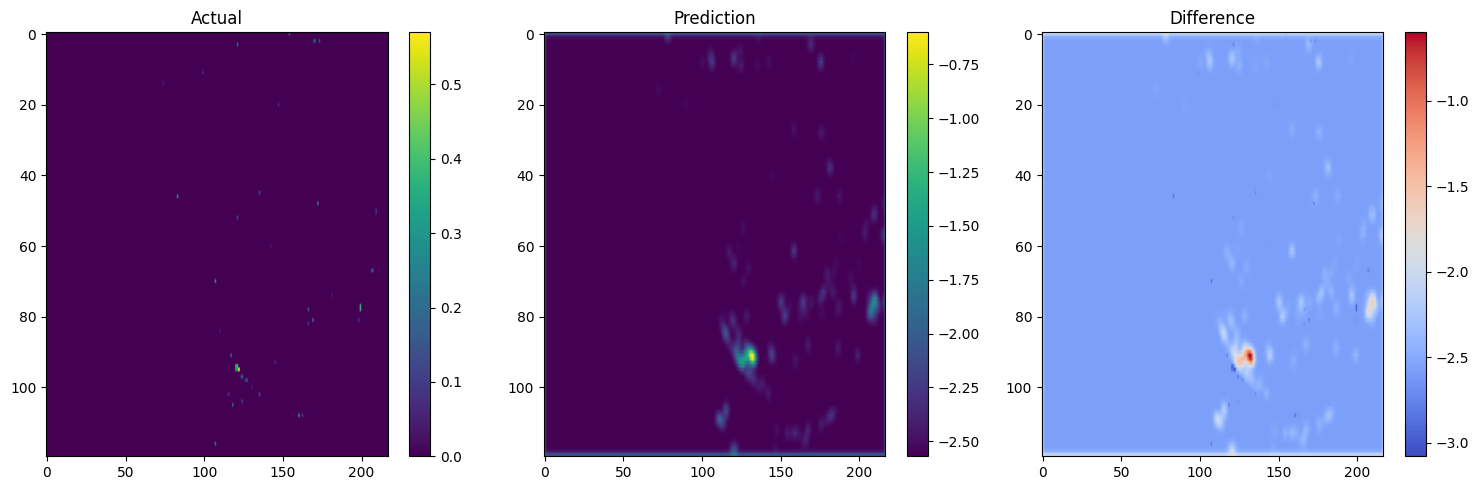

In [15]:
import matplotlib.pyplot as plt
import torch

model.eval()

# get one batch
inputs, labels = next(iter(test_loader),4)
inputs = inputs.to(device)
labels = labels.to(device)

with torch.no_grad():
    outputs = model(inputs)
sample_no=6
# pick one sample from the batch
pred = outputs[sample_no]
actual = labels[sample_no]

# if shape is [1, H, W], remove the channel dimension
if pred.dim() == 3:
    pred = pred.squeeze(0)

if actual.dim() == 3:
    actual = actual.squeeze(0)

# move to cpu and convert to numpy
pred = pred.cpu().numpy()
actual = actual.cpu().numpy()

diff = pred - actual

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(actual, aspect='auto', cmap='viridis')
plt.title("Actual")
plt.colorbar()

plt.subplot(1, 3, 2)
plt.imshow(pred, aspect='auto', cmap='viridis')
plt.title("Prediction")
plt.colorbar()

plt.subplot(1, 3, 3)
plt.imshow(diff, aspect='auto', cmap='coolwarm')
plt.title("Difference")
plt.colorbar()

plt.tight_layout()
plt.show()

C:\TEMP\ipykernel_10732\3276092173.py:23: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  target = torch.tensor(target, dtype=torch.float32)


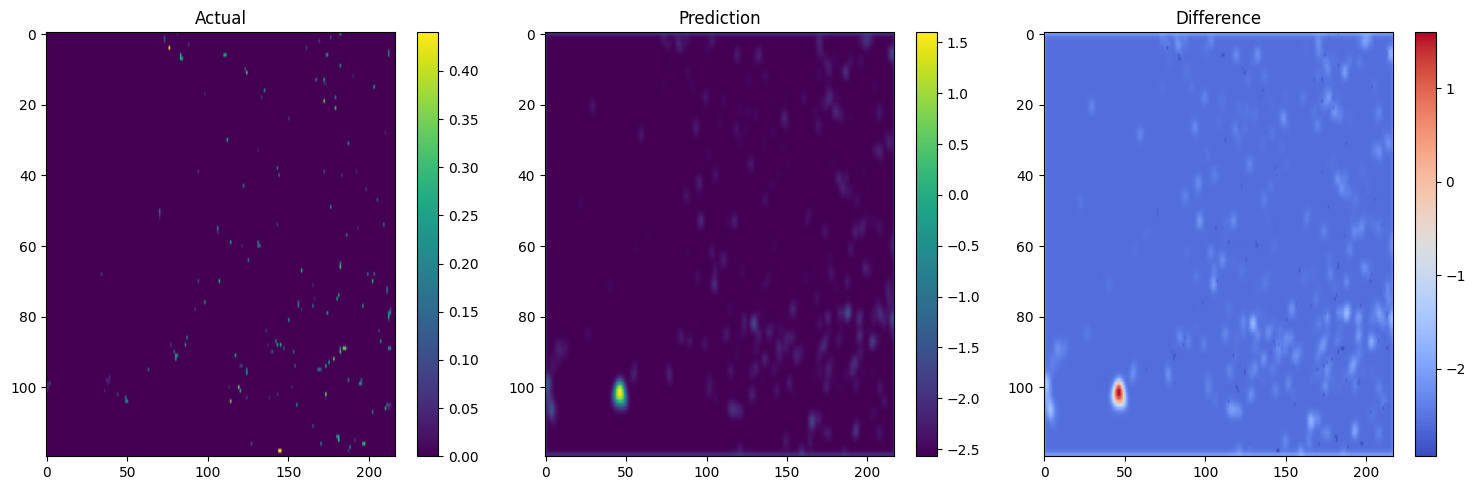

In [16]:
import matplotlib.pyplot as plt
import torch

model.eval()

# get one batch
inputs, labels = next(iter(train_loader),3)
inputs = inputs.to(device)
labels = labels.to(device)

with torch.no_grad():
    outputs = model(inputs)
sample_no=6
# pick one sample from the batch
pred = outputs[sample_no]
actual = labels[sample_no]

# if shape is [1, H, W], remove the channel dimension
if pred.dim() == 3:
    pred = pred.squeeze(0)

if actual.dim() == 3:
    actual = actual.squeeze(0)

# move to cpu and convert to numpy
pred = pred.cpu().numpy()
actual = actual.cpu().numpy()

diff = pred - actual

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(actual, aspect='auto', cmap='viridis')
plt.title("Actual")
plt.colorbar()

plt.subplot(1, 3, 2)
plt.imshow(pred, aspect='auto', cmap='viridis')
plt.title("Prediction")
plt.colorbar()

plt.subplot(1, 3, 3)
plt.imshow(diff, aspect='auto', cmap='coolwarm')
plt.title("Difference")
plt.colorbar()

plt.tight_layout()
plt.show()

C:\TEMP\ipykernel_10732\3276092173.py:23: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  target = torch.tensor(target, dtype=torch.float32)


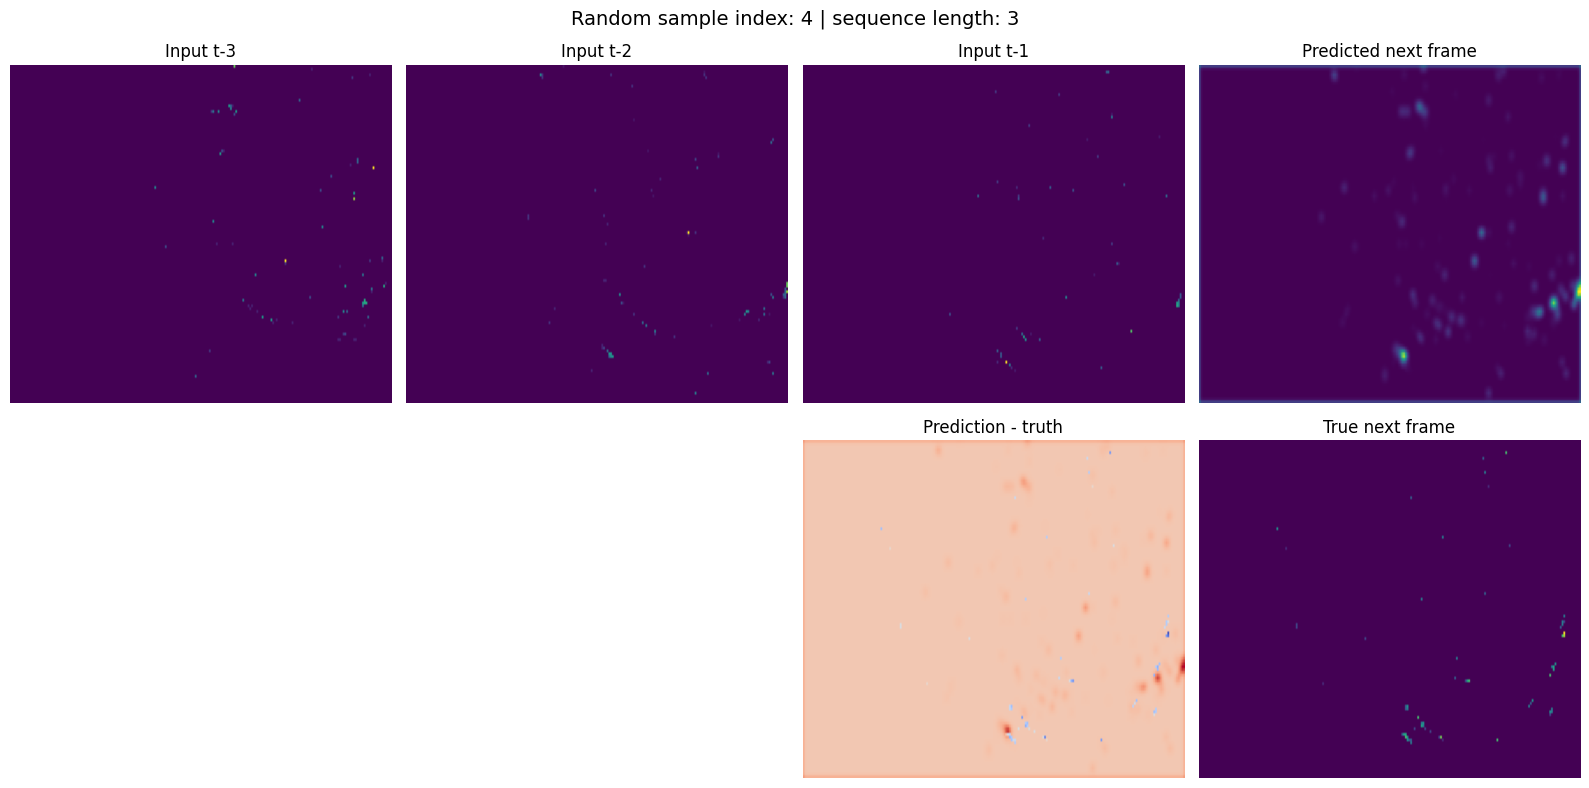

In [17]:
import matplotlib.pyplot as plt

model.eval()

sample_idx = 4
sample_inputs, sample_target = test_dataset[sample_idx] if len(test_dataset) > 0 else dataset[sample_idx]

with torch.no_grad():
    sample_batch = sample_inputs.unsqueeze(0).to(device)
    sample_outputs = model(sample_batch)
    sample_prediction = torch.sigmoid(sample_outputs)[0].cpu()

sample_inputs = sample_inputs.cpu()
sample_target = sample_target.cpu()

num_steps = sample_inputs.shape[0]
fig, axes = plt.subplots(2, max(num_steps + 1, 3), figsize=(4 * max(num_steps + 1, 3), 8))
axes = axes.reshape(2, -1)

for step in range(axes.shape[1]):
    axes[0, step].axis('off')
    axes[1, step].axis('off')

for step in range(num_steps):
    input_frame = sample_inputs[step]
    if input_frame.dim() == 3:
        input_frame = input_frame.squeeze(0)
    axes[0, step].imshow(input_frame.numpy(), aspect='auto', cmap='viridis')
    axes[0, step].set_title(f'Input t-{num_steps - step}')
    axes[0, step].axis('off')

pred_frame = sample_prediction
if pred_frame.dim() == 3:
    pred_frame = pred_frame.squeeze(0)
axes[0, num_steps].imshow(pred_frame.numpy(), aspect='auto', cmap='viridis')
axes[0, num_steps].set_title('Predicted next frame')
axes[0, num_steps].axis('off')

target_frame = sample_target
if target_frame.dim() == 3:
    target_frame = target_frame.squeeze(0)
diff_frame = pred_frame.numpy() - target_frame.numpy()
axes[1, num_steps - 1].imshow(diff_frame, aspect='auto', cmap='coolwarm')
axes[1, num_steps - 1].set_title('Prediction - truth')
axes[1, num_steps - 1].axis('off')

axes[1, num_steps].imshow(target_frame.numpy(), aspect='auto', cmap='viridis')
axes[1, num_steps].set_title('True next frame')
axes[1, num_steps].axis('off')

fig.suptitle(f'Random sample index: {sample_idx} | sequence length: {num_steps}', fontsize=14)
plt.tight_layout()
plt.show()

In [18]:
from pathlib import Path
from datetime import datetime

save_dir = Path(r"C:\Users\Jacobs laptop\rainraingoaway\models")
save_dir.mkdir(parents=True, exist_ok=True)

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
model_path = save_dir / f"model_best_{timestamp}.pkl"
torch.save(model.state_dict(), model_path)
print(f"saved to {model_path}")

saved to C:\Users\Jacobs laptop\rainraingoaway\models\model_best_20260609_124847.pkl
